# Chapter 6: Other computer vision problems

In [1]:
! pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 15.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.0 MB/s eta 0:00:0000:01


In [2]:
from fastai.vision.all import *
from fastbook import *

In [3]:
def list_methods(var):
    return [a for a in dir(var) if callable(getattr(var, a))]

## Part 1: Multi-label data

### Block 1: Multi-label vs. single-label: when labels aren't mutually exclusive

In some datasets, data metadata is stored in a csv file that specifies, among other things, where the actual data files live. The PASCAL dataset falls into this category, and that's what we're using for this chapter.

In [4]:
path = untar_data(URLs.PASCAL_2007)
path

<div><progress max="1637796771" value="1637801984"></progress> 100.00% [1637801984/1637796771 00:41&lt;00:00]</div>

Path('/root/.fastai/data/pascal_2007')

In [5]:
Path.BASE_PATH = path
path.ls()

[Path('test.json'), Path('train.csv'), Path('test'), Path('valid.json'), Path('train'), Path('test.csv'), Path('segmentation'), Path('train.json')]

Notice the `train.csv` and `test.csv` files.

In [6]:
(path/'train').ls()

(#5012) [Path('train/009528.jpg'), Path('train/009721.jpg'), Path('train/006269.jpg'), Path('train/007762.jpg'), Path('train/001586.jpg'), Path('train/004846.jpg'), Path('train/006628.jpg'), Path('train/007899.jpg'), Path('train/001981.jpg'), Path('train/008722.jpg'), Path('train/000030.jpg'), Path('train/004955.jpg'), Path('train/005421.jpg'), Path('train/005230.jpg'), Path('train/007330.jpg'), Path('train/002411.jpg'), Path('train/003658.jpg'), Path('train/002657.jpg'), Path('train/008398.jpg'), Path('train/000777.jpg'), Path('train/004244.jpg'), Path('train/003063.jpg'), Path('train/000009.jpg'), Path('train/009809.jpg'), Path('train/001231.jpg'), Path('train/009654.jpg'), Path('train/006802.jpg'), Path('train/009792.jpg'), Path('train/004185.jpg'), Path('train/008468.jpg'), Path('train/001517.jpg'), Path('train/001521.jpg'), Path('train/004196.jpg'), Path('train/007606.jpg'), Path('train/006983.jpg'), Path('train/009022.jpg'), Path('train/009443.jpg'), Path('train/003859.jpg'), Pat

To better understand the data, we need to look at the contents of the CSV files. For that we'll use pandas.

In [7]:
import pandas as pd

In [8]:
train = pd.read_csv((path/'train.csv'))
train

,fname,labels,is_valid
0,000005.jpg,chair,True
1,000007.jpg,car,True
2,000009.jpg,horse person,True
3,000012.jpg,car,False
4,000016.jpg,bicycle,True
...,...,...,...
5006,009954.jpg,horse person,True
5007,009955.jpg,boat,True
5008,009958.jpg,person bicycle,True
5009,009959.jpg,car,False


The columns are clear:
- `fname` is the filename
- `labels` tells us the labels for the image; we can see that a space-separated list of values indicates that there are multiple appropriate labels for an image
- `is_valid` indicates whether the image should be in the training or validation set

Let's find the rows that have multiple labels.

In [9]:
multi_label_train = train[train['labels'].str.contains(' ')]
multi_label_train

,fname,labels,is_valid
2,000009.jpg,horse person,True
5,000017.jpg,person horse,False
8,000021.jpg,dog person,True
9,000023.jpg,bicycle person,False
12,000030.jpg,bicycle person,True
...,...,...,...
5003,009947.jpg,boat person,True
5004,009949.jpg,sofa chair person,False
5005,009950.jpg,train person,True
5006,009954.jpg,horse person,True


So a little less than half of the rows have multiple labels. Let's see what the test data looks like.

In [10]:
test = pd.read_csv(path/'test.csv')
test

,fname,labels
0,000001.jpg,dog person
1,000002.jpg,train
2,000003.jpg,sofa chair
3,000004.jpg,car
4,000006.jpg,pottedplant diningtable chair
...,...,...
4947,009956.jpg,cat
4948,009957.jpg,person horse
4949,009960.jpg,motorbike person
4950,009962.jpg,chair person diningtable


Obviously the `is_valid` column is no longer needed here.

### Block 2: Building a `DataBlock` incrementally

Let's use the `DataBlock` to organize the data into a format that is easily accessible to python and fastai.

In [11]:
dblock = DataBlock()
dblock.datasets(train)[0]

(fname       000005.jpg
 labels           chair
 is_valid          True
 Name: 0, dtype: object,
 fname       000005.jpg
 labels           chair
 is_valid          True
 Name: 0, dtype: object)

A dataset object is a list of 2-member tuples where the first member is the input data and the second member is the output label. Here we can see that the tuple just contains the full row twice, so clearly something isn't quite right. Let's tell the `DataBlock` how to extract the specific input and output values.

The input values are the images, and the output values are the labels. So those are the values we need to get from each row.

In [12]:
dblock = DataBlock(
    get_x=lambda row: row['fname'],
    get_y=lambda row: row['labels'],
)
dblock.datasets(train)[0]

('000005.jpg', 'chair')

`get_x` and `get_y` can be either lambda functions or named functions. Named functions are compatible with exporting models because they can be serialized, so let's use them instead.

In [13]:
def get_x(row):
    return row['fname']

def get_y(row):
    return row['labels']

In [14]:
dblock = DataBlock(
    get_y=get_y,
    get_x=get_x,
)
dblock.datasets(train)[0]

('000005.jpg', 'chair')

Still working! Now let's confirm what that looks like for multi-label rows:

In [15]:
dblock.datasets(multi_label_train)[0]

('000009.jpg', 'horse person')

At this point we can see 2 problems:
- the input data is just a filename, we'll need to load the actual image file to work with it
- the output label needs to be transformed into a list of the individual labels, rather than maintaining the space-separated list

In [16]:
def get_x(row):
    img = path/'train'/row['fname']
    return img

def get_y(row):
    return row['labels'].split(' ')

In [17]:
dblock = DataBlock(
    blocks=(ImageBlock, MultiCategoryBlock),
    get_y=get_y,
    get_x=get_x,
)
multi_label_dsets = dblock.datasets(multi_label_train)
multi_label_dsets[0]

(PILImage mode=RGB size=500x375,
 TensorMultiCategory([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0.]))

For the input data, we first had to combine the image name with the appropriate path. Then use `ImageBlock` to handle the conversion of the image into a tensor-compatible format.

For the output label, we used `MultiCategoryBlock` rather than `CategoryBlock` because each image can have multiple categories. The `1` values are the labels that are present for a given image, and the `0` values are the labels that are absent. This is called one-hot encoding. It takes advantage of pytorch's capacities by maintaining a same-sized list of values for the categories, so that tensor operations can proceed smoothly.

To understand what the categories correspond to, let's look at the `.vocab` property of the dataset.

In [18]:
multi_label_dsets.train.vocab

['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']

So we can identify the labels present in that first image as follows:

In [19]:
idxs = torch.where(dblock.datasets(multi_label_train)[0][1]==1)
[multi_label_dsets.train.vocab[i] for i in idxs]

[['horse', 'person']]

Now we don't actually know if the dataset contains the correct split of validation and training data. Let's check:

In [20]:
train[train['is_valid']==True].shape

(2510, 3)

In [21]:
train[train['is_valid']==False].shape

(2501, 3)

In [22]:
dset = dblock.datasets(train)
len(dset.train)

4009

Clearly the split was wrong. Fastai uses a default random splitter of 20% for the validation set, so that explains this number. We should specify the correct split based on the `is_valid` column.

In [23]:
def splitter(df):
    # return 2 lists of indexes for training and validation rows
    valid = df[df['is_valid']].index
    train = df[~df['is_valid']].index

    return train, valid

In [24]:
dblock = DataBlock(
    blocks=(ImageBlock, MultiCategoryBlock),
    get_y=get_y,
    get_x=get_x,
    splitter=splitter,
)
dset = dblock.datasets(train)
len(dset.train), len(dset.valid)

(2501, 2510)

Much better! Now we must ensure that the data are all in the same shape, which is needed for GPU acceleration and pytorch operations.

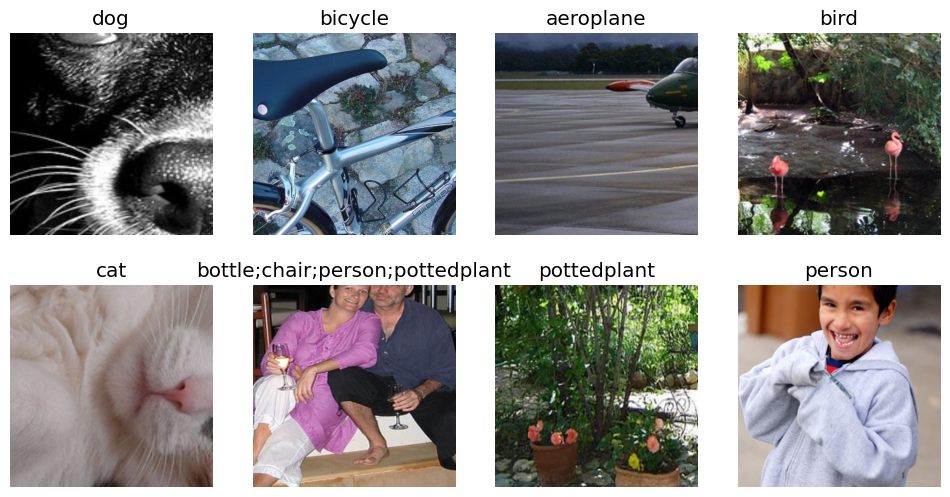

In [25]:
dblock = DataBlock(
    blocks=(ImageBlock, MultiCategoryBlock),
    get_y=get_y,
    get_x=get_x,
    splitter=splitter,
    item_tfms=RandomResizedCrop(460),
)

dls = dblock.dataloaders(train)
dls.show_batch(nrows=2, ncols=4)

### Block 3: One-hot encoding: what a multi-label target looks like as a tensor

As we've seen previously, the `TensorMultiCategory` object contains 20 members, which is the total number of distinct categories present in our data. We also previously identified the specific labels present in a particular image. Now let's confirm that the labels correspond to what's actually specified in the `labels` column for that image in the dataframe.

In [26]:
dblock.summary(train)

Setting-up type transforms pipelines
0     000005.jpg           chair      True
1     000007.jpg             car      True
2     000009.jpg    horse person      True
3     000012.jpg             car     False
4     000016.jpg         bicycle      True
...          ...             ...       ...
5006  009954.jpg    horse person      True
5007  009955.jpg            boat      True
5008  009958.jpg  person bicycle      True
5009  009959.jpg             car     False
5010  009961.jpg             dog     False

[5011 rows x 3 columns]
Found 5011 items
2 datasets of sizes 2501,2510
Setting up Pipeline: get_x -> PILBase.create
Setting up Pipeline: get_y -> MultiCategorize -- {'vocab': None, 'sort': True, 'add_na': False}
 -> OneHotEncode -- {'c': None}


Building one sample
  Pipeline: get_x -> PILBase.create
    starting from
      fname       000012.jpg
labels             car
is_valid         False
Name: 3, dtype: object
    applying get_x gives
      /root/.fastai/data/pascal_2007/train/000

This file shows up in the summary:

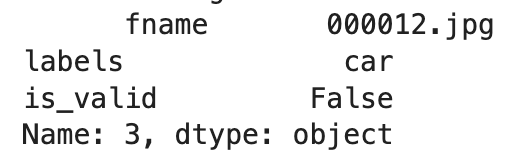

With the following output label tensor:

```python
[0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]
```

There's only 1 label with a value of `1`, so let's find the corresponding name:

In [27]:
idx = torch.where(tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])==1)[0]
dls.vocab[idx]

['car']

And it's a match!

## Part 2: Binary Cross Entropy

### Block 4: Model activations for a multi-label batch

Let's look at the model's output for a multi-label classification task. To do this, we'll inspect the outputs of a stock model i.e. without fine-tuning.

In [30]:
# get a mini-batch
x,y = dls.one_batch()
x.shape, y.shape

(torch.Size([64, 3, 460, 460]), torch.Size([64, 20]))

In [32]:
y[0], y[0].shape

(TensorMultiCategory([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 torch.Size([20]))

The `y` values have the same shape we saw earlier when building the data block, which is expected. Now let's see the model's predictions:

In [35]:
learn = vision_learner(dls, resnet18)
# .model() returns the model's outputs
preds = learn.model(x)
preds.shape

torch.Size([64, 20])

The `preds` tensor is the model's predictions for each label, and as we can see it is the same shape of `TensorMultiCategory` as `y`, which is what we expect.

Now let's see the set of predictions for the first image in the mini-batch:

In [36]:
preds[0]

TensorImage([-0.4644, -1.2544, -2.5463, -2.9969,  5.4285, -5.8759,  3.1495,  2.0176, -2.2324,  1.9535, -3.6125,  0.7837, -2.9789,  1.7480,  1.4758,  2.5718,  5.1570, -4.0802, -2.9017,  1.0780],
            grad_fn=<AliasBackward0>)

Clearly these values have not been transformed by any activation function because they're not constrained to values between `0` and `1`. Now let's see what they look like after an activation function is applied. In this case we'll use sigmoid because this is a multi-label classification task.

In [42]:
preds.sigmoid()[0]

TensorImage([0.3859, 0.2219, 0.0727, 0.0476, 0.9956, 0.0028, 0.9589, 0.8826, 0.0969, 0.8758, 0.0263, 0.6865, 0.0484, 0.8517, 0.8139, 0.9290, 0.9943, 0.0166, 0.0521, 0.7461], grad_fn=<AliasBackward0>)

Some observations:
- the labels that the model gave the highest confidence values are all wrong. This is a stock model without fine-tuning, so this is not surprising
- the predictions do not all sum up to 1; this is the natural of using sigmoid. Each label is transformed to a value between `0` and `1` but all values are not constrained to sum up to 1.

The next question now is why did we use sigmoid instead of softmax?